In [51]:
import math
import random
from random import uniform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.feature import hog
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Exercise 1 : Linear SVM - Influence of parameter C

In [52]:
dataset = pd.read_csv('LineaireNoisy2.csv', delimiter=';')
dataset

,x1,x2,y
0,10.00,5.00,1
1,9.50,10.00,-1
2,2.30,5.25,-1
3,3.40,3.88,-1
4,7.66,4.46,-1
...,...,...,...
147,15.01,15.67,1
148,16.05,14.70,1
149,15.65,18.23,1
150,18.85,17.43,1


In [53]:
print("Possible values of y:", sorted(dataset.y.unique()))
print(dataset.y.value_counts())
# Answer: y is -1 or +1, 76 examples of each.

Possible values of y: [np.int64(-1), np.int64(1)]
y
 1    76
-1    76
Name: count, dtype: int64


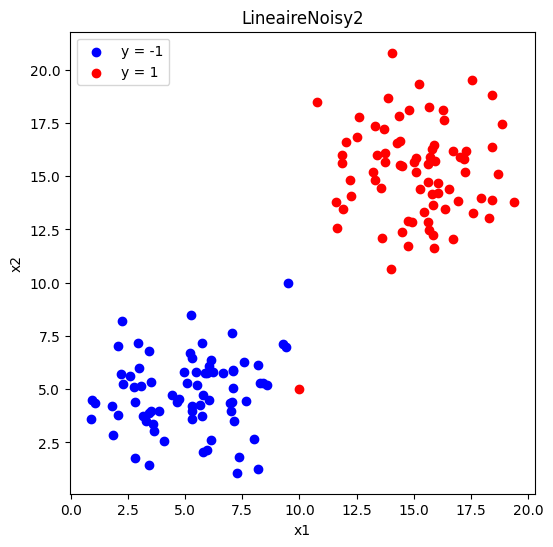

In [54]:
plt.figure(figsize=(6, 6))
plt.scatter(dataset.x1[dataset.y == -1], dataset.x2[dataset.y == -1], c="blue", label="y = -1")
plt.scatter(dataset.x1[dataset.y == 1], dataset.x2[dataset.y == 1], c="red", label="y = 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("LineaireNoisy2")
plt.show()

## Fitting a linear SVM to this dataset

In [55]:
model_svm = svm.SVC(C = 1000, kernel = 'linear')
# here SVC stands for Support Vector Classification (there are other kinds of SVM),and we ask for a linear kernel
# The parameter C is set to 1000

In [56]:
model_svm.fit(dataset.iloc[:,0:2], dataset.y)
# here we ask to fit the model using the features (x1 and x2) and the target (y)

,C,1000
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [57]:
model_svm.support_vectors_
# the support vectors found by the SVC. Here 3 support vectors, called sv1, sv2 and sv3

array([[ 9.41,  6.97],
       [10.  ,  5.  ],
       [10.78, 18.49]])

In [58]:
model_svm.support_
# the index of the support vectors in the dataset. you can check 

array([ 61,   0, 102], dtype=int32)

In [59]:
model_svm.dual_coef_
# the lagrange coefficients associated to the support vectors (w1, w2 and w3)

array([[-4.04838982,  3.46935572,  0.5790341 ]])

In [60]:
model_svm.intercept_
# the constant of the model (w0)

array([-26.58177221])

In [61]:
model_svm.decision_function(dataset.iloc[:,0:2])

array([  0.99940407,  -1.24148389, -20.91114918, -17.56203656,
        -5.55801067, -10.10889154,  -3.90822106, -21.76685665,
       -10.39666304, -18.76130279, -13.09448448, -15.41565599,
       -22.18728362,  -3.62255982, -16.27032034, -17.78695937,
        -7.43350422, -17.49256868, -17.13473082,  -7.38326661,
       -19.5516331 , -12.85908729, -16.87859157, -18.21741848,
        -4.32685023, -10.06558557,  -6.0540296 , -12.56078853,
       -12.99192542, -11.72582313,  -7.3553862 , -12.18372041,
        -7.47457014, -24.64741494, -10.16024918, -18.04301931,
       -14.80785344, -21.27232307,  -1.34003152, -17.23762877,
        -7.28068112, -13.86615894, -19.43865014, -10.60139177,
        -7.27870065, -10.47191611,  -5.97833429, -10.88212828,
        -3.49899913, -12.14974236,  -4.26845759, -20.12147022,
       -11.9679693 , -11.42929574, -14.07039256, -24.64824895,
        -6.91064799, -19.1329775 , -16.77089868,  -8.609971  ,
        -9.54137378,  -0.99970304, -10.91975481,  -7.86

In [62]:
print("Support vector indices:", model_svm.support_)
print("Decision values on the 3 SVs:", model_svm.decision_function(model_svm.support_vectors_))
# Expected: they lie on the margin, so h(x) is about +1 or -1.

Support vector indices: [ 61   0 102]
Decision values on the 3 SVs: [-0.99970304  0.99940407  1.00026691]


/Users/ardjood/jupyter_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [63]:
print("Accuracy on the full dataset:", model_svm.score(dataset.iloc[:, 0:2], dataset.y))
# Answer: 1.0

Accuracy on the full dataset: 1.0


In [64]:
def svm_draw(model_svm, xmin, xmax, dataset):
    
    color_map = matplotlib.colors.ListedColormap(pd.Series(['blue', 'red']))


    plt.figure(figsize=(10, 8))
    # Plotting our two-features-space
    plt.scatter(dataset.iloc[:,0], dataset.iloc[:,1], c = dataset.y, cmap = color_map, marker='+')
    # Constructing a hyperplane using a formula.
    w = model_svm.coef_[0]           # w consists of 2 elements
    b = model_svm.intercept_[0]      # b consists of 1 element
    x_points = np.linspace(xmin, xmax)    # generating x-points from -1 to 1
    y_points = -(w[0] / w[1]) * x_points - b / w[1]  # getting corresponding y-points

    plt.plot(x_points, y_points, c='g');

    plt.scatter(model_svm.support_vectors_[:, 0],
                model_svm.support_vectors_[:, 1], 
                s=50, 
                facecolors='none', 
                edgecolors='k', 
                alpha=1);

    # Step 2 (unit-vector):
    w_hat = model_svm.coef_[0] / (np.sqrt(np.sum(model_svm.coef_[0] ** 2)))
    # Step 3 (margin):
    margin = 1 / np.sqrt(np.sum(model_svm.coef_[0] ** 2))
    # Step 4 (calculate points of the margin lines):
    decision_boundary_points = np.array(list(zip(x_points, y_points)))
    points_of_line_above = decision_boundary_points + w_hat * margin
    points_of_line_below = decision_boundary_points - w_hat * margin
    # Plot margin lines
    # Blue margin line above
    plt.plot(points_of_line_above[:, 0], 
             points_of_line_above[:, 1], 
             'g--', 
             linewidth=2)
    # Green margin line below
    plt.plot(points_of_line_below[:, 0], 
             points_of_line_below[:, 1], 
             'g--',
             linewidth=2)

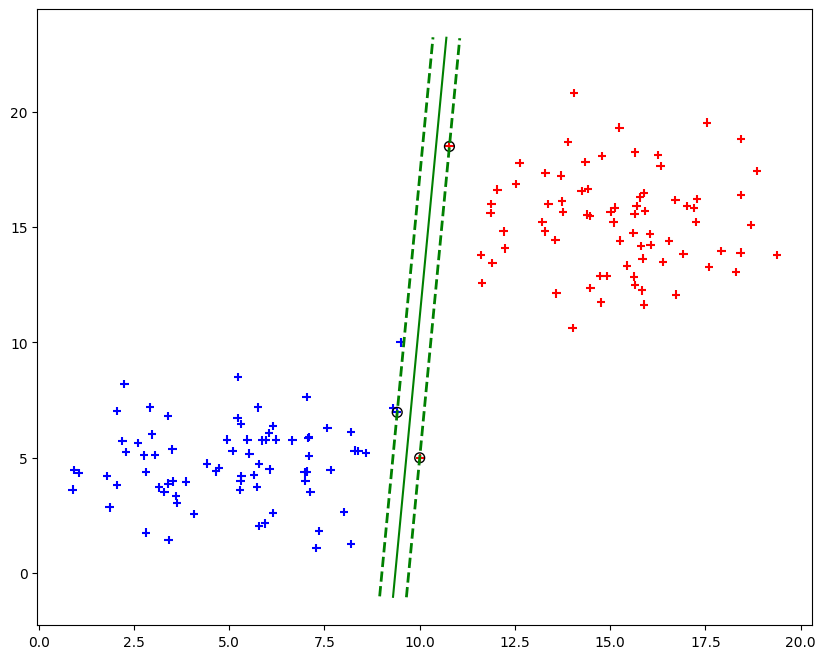

In [65]:
svm_draw(model_svm, 9.3, 10.7, dataset)

In [66]:
model_svm_c1 = svm.SVC(C=1, kernel="linear").fit(dataset.iloc[:, 0:2], dataset.y)
print("Number of support vectors:", len(model_svm_c1.support_), model_svm_c1.n_support_)
print("Train score:", model_svm_c1.score(dataset.iloc[:, 0:2], dataset.y))
# Answer: 4 support vectors (2 per class), train score about 0.993.

Number of support vectors: 4 [2 2]
Train score: 0.993421052631579


In [67]:
print(model_svm_c1.support_vectors_)
print(model_svm_c1.dual_coef_)
print(model_svm_c1.intercept_)

[[ 9.5  10.  ]
 [ 9.41  6.97]
 [10.    5.  ]
 [10.78 18.49]]
[[-1.         -0.43774553  1.          0.43774553]]
[-11.64679251]


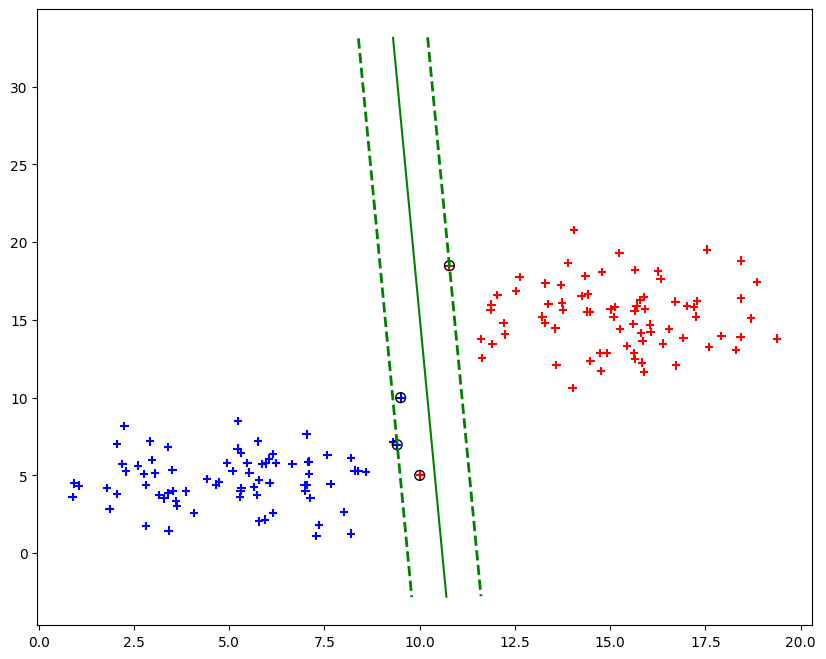

In [68]:
svm_draw(model_svm_c1, 9.3, 10.7, dataset)

In [69]:
# C=1: a few more support vectors than C=1000, slightly wider margin, train score just below 1.

In [70]:
print("""ANSWER (C=1):
4 support vectors (2 per class). Train accuracy = 0.9934 (1 misclassified point).
Wider margin than C=1000. The 4 SVs are on or inside the margins
(h(x) ≈ -0.77, -1.00, -0.44, +1.00).""")

ANSWER (C=1):
4 support vectors (2 per class). Train accuracy = 0.9934 (1 misclassified point).
Wider margin than C=1000. The 4 SVs are on or inside the margins
(h(x) ≈ -0.77, -1.00, -0.44, +1.00).


In [71]:
model_svm_c001 = svm.SVC(C=0.01, kernel="linear").fit(dataset.iloc[:, 0:2], dataset.y)
print("Number of support vectors:", len(model_svm_c001.support_), model_svm_c001.n_support_)
print("Train score:", model_svm_c001.score(dataset.iloc[:, 0:2], dataset.y))
# Answer: 12 support vectors, train score about 0.993.

Number of support vectors: 12 [6 6]
Train score: 0.993421052631579


In [72]:
print(model_svm_c001.support_vectors_)
print(model_svm_c001.dual_coef_)
print(model_svm_c001.intercept_)

[[ 9.5  10.  ]
 [ 5.24  8.5 ]
 [ 8.19  6.13]
 [ 9.3   7.14]
 [ 9.41  6.97]
 [ 7.03  7.64]
 [10.    5.  ]
 [11.61 13.78]
 [14.01 10.63]
 [11.91 13.44]
 [11.63 12.56]
 [13.59 12.12]]
[[-0.01       -0.00062732 -0.01       -0.01       -0.01       -0.01
   0.01        0.01        0.01        0.01        0.01        0.00062732]]
[-3.36105283]


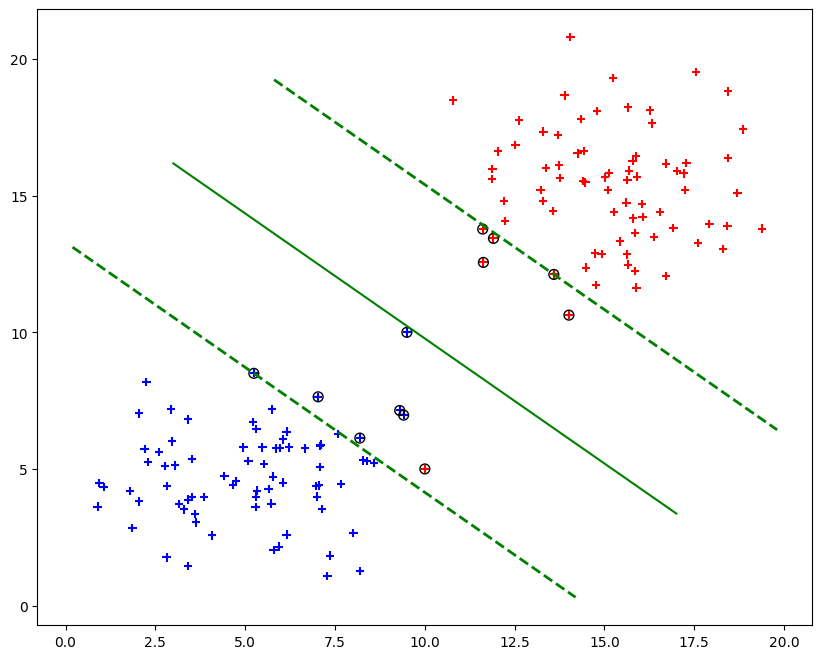

In [73]:
svm_draw(model_svm_c001, 3, 17, dataset)

In [74]:
print("""ANSWER (C=0.01):
12 support vectors (6 per class), much wider margin (need xmin=3, xmax=17 to see it).
Train accuracy = 0.9934 (still 1 error) but the boundary is more stable / less glued to noisy points.""")

ANSWER (C=0.01):
12 support vectors (6 per class), much wider margin (need xmin=3, xmax=17 to see it).
Train accuracy = 0.9934 (still 1 error) but the boundary is more stable / less glued to noisy points.


# Exercise 2: Choosing C using train/val/test split

In [75]:
# Load the dataset
dataset = pd.read_csv("spam7.csv", decimal=",", index_col=0, delimiter = ";")
dataset
# A description about this dataset is given here:
# http://math.furman.edu/~dcs/courses/math47/R/library/DAAG/html/spam7.html

,crl.tot,dollar,bang,money,n000,make,yesno
0,278,0.000,0.778,0.00,0.00,0.00,y
1,1028,0.180,0.372,0.43,0.43,0.21,y
2,2259,0.184,0.276,0.06,1.16,0.06,y
3,191,0.000,0.137,0.00,0.00,0.00,y
4,191,0.000,0.135,0.00,0.00,0.00,y
...,...,...,...,...,...,...,...
4596,88,0.000,0.000,0.00,0.00,0.31,n
4597,14,0.000,0.353,0.00,0.00,0.00,n
4598,118,0.000,0.000,0.00,0.00,0.30,n
4599,78,0.000,0.000,0.00,0.00,0.96,n


In [76]:
print("Examples:", dataset.shape[0])
print("Features:", dataset.shape[1] - 1)
print(dataset.yesno.value_counts())
# Answer: 4601 emails, 6 features, target yesno = n (2788, not spam) or y (1813, spam).

Examples: 4601
Features: 6
yesno
n    2788
y    1813
Name: count, dtype: int64


In [77]:
# First, get the features
X = dataset.iloc[:,0:6]
# then create a scaler on X
scaler = StandardScaler().fit(X)
# Apply it to X
X = scaler.transform(X)
# create a dataframe with X
X = pd.DataFrame(X, columns=dataset.columns[0:6])
X
# You should see that the features have been transformed
print(X.dollar.mean())
# the mean of feature 'dollar' is now 0 (very close to 0)
# it is the same for the other features

-2.470915838331146e-17


In [78]:
# Now we will add the target variable inside X
X['yesno'] = dataset.yesno
X
# now our dataset is called X

,crl.tot,dollar,bang,money,n000,make,yesno
0,-0.008724,-0.308355,0.624007,-0.212994,-0.290209,-0.342434,y
1,1.228324,0.423783,0.126203,0.758565,0.937491,0.345359,y
2,3.258733,0.440053,0.008496,-0.077428,3.021726,-0.145921,y
3,-0.152222,-0.308355,-0.161934,-0.212994,-0.290209,-0.342434,y
4,-0.152222,-0.308355,-0.164387,-0.212994,-0.290209,-0.342434,y
...,...,...,...,...,...,...,...
4596,-0.322110,-0.308355,-0.329912,-0.212994,-0.290209,0.672880,n
4597,-0.444165,-0.308355,0.102907,-0.212994,-0.290209,-0.342434,n
4598,-0.272628,-0.308355,-0.329912,-0.212994,-0.290209,0.640128,n
4599,-0.338604,-0.308355,-0.329912,-0.212994,-0.290209,2.801763,n


In [79]:
data_train, temp = train_test_split(X, test_size=0.30, random_state=4)
data_valid, data_test = train_test_split(temp, test_size=0.50, random_state=4)
print("train:", data_train.shape, "val:", data_valid.shape, "test:", data_test.shape)

train: (3220, 7) val: (690, 7) test: (691, 7)


In [80]:
print(data_train.yesno.value_counts())

yesno
n    1939
y    1281
Name: count, dtype: int64


In [81]:
model_svm = svm.SVC(C=1, kernel="linear").fit(data_train.iloc[:, 0:6], data_train.yesno)
print("Number of support vectors:", len(model_svm.support_), model_svm.n_support_)
# Answer: about 1264 support vectors.

Number of support vectors: 1264 [632 632]


In [82]:
print("Train accuracy:", model_svm.score(data_train.iloc[:, 0:6], data_train.yesno))
# Answer: about 0.85

Train accuracy: 0.8496894409937888


In [83]:
print("Validation accuracy:", model_svm.score(data_valid.iloc[:, 0:6], data_valid.yesno))
# Answer: about 0.85

Validation accuracy: 0.8492753623188406


In [84]:
print("C=1 linear SVM: ~1264 SVs, train and val both about 0.85")

C=1 linear SVM: ~1264 SVs, train and val both about 0.85


In [85]:
print(model_svm.n_support_)

[632 632]


In [86]:
Cs = [0.01, 0.1, 1, 10, 100, 1000]
rows = []
saved = {}
for C in Cs:
    m = svm.SVC(C=C, kernel="linear").fit(data_train.iloc[:, 0:6], data_train.yesno)
    tr = m.score(data_train.iloc[:, 0:6], data_train.yesno)
    va = m.score(data_valid.iloc[:, 0:6], data_valid.yesno)
    print(f"C={C:<7} n_sv={len(m.support_):4d}  train={tr:.4f}  val={va:.4f}")
    rows.append((C, va, tr))
    saved[C] = m

best_val = max(r[1] for r in rows)
best_C = min(C for C, va, tr in rows if va == best_val)
print("Selected C:", best_C)
print("Test accuracy:", saved[best_C].score(data_test.iloc[:, 0:6], data_test.yesno))
print("Estimated generalization error:", 1 - saved[best_C].score(data_test.iloc[:, 0:6], data_test.yesno))
# Answer: C=1 (smallest C among the best val scores). Test about 0.85, gen. error about 0.15.

C=0.01    n_sv=1582  train=0.8264  val=0.8377
C=0.1     n_sv=1315  train=0.8491  val=0.8464
C=1       n_sv=1264  train=0.8497  val=0.8493
C=10      n_sv=1258  train=0.8497  val=0.8493
C=100     n_sv=1257  train=0.8497  val=0.8493
C=1000    n_sv=1257  train=0.8494  val=0.8493
Selected C: 1
Test accuracy: 0.8480463096960926
Estimated generalization error: 0.15195369030390737


In [87]:
print("""ANSWER: validation plateaus from C=1 upward (val ≈ 0.849). Keep the simplest model: C=1.
Test accuracy ≈ 0.848, estimated generalization error ≈ 0.152.
Do not re-compare C on the test set.""")

ANSWER: validation plateaus from C=1 upward (val ≈ 0.849). Keep the simplest model: C=1.
Test accuracy ≈ 0.848, estimated generalization error ≈ 0.152.
Do not re-compare C on the test set.


# Exercise 3: Non-linear SVM

In [88]:
# Load a dataset
dataset = pd.read_csv("SepNonLineaire.csv")
dataset


,x1,x2,y
0,1.5,4.0,1
1,1.0,2.0,1
2,0.0,0.0,1
3,1.0,4.0,1
4,0.5,3.0,1
...,...,...,...
145,-2.8,-3.3,0
146,-2.8,1.0,0
147,-2.8,3.0,0
148,-2.4,3.0,0


In [89]:
print("Examples:", dataset.shape[0])
print("Features:", dataset.shape[1] - 1)
print(dataset.y.value_counts())
# Answer: 150 points, 2 features, y=0 (105) and y=1 (45).

Examples: 150
Features: 2
y
0    105
1     45
Name: count, dtype: int64


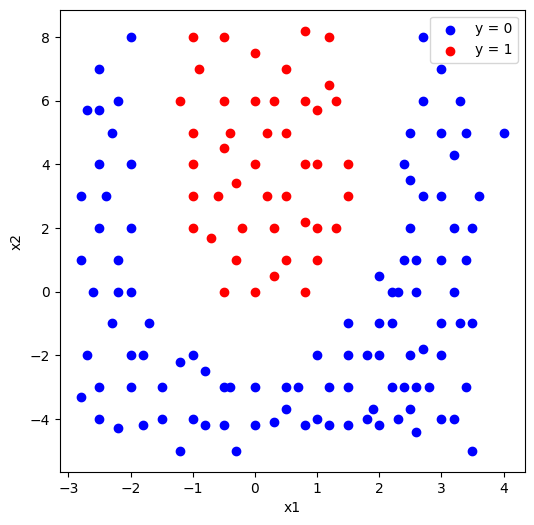

In [90]:
plt.figure(figsize=(6, 6))
plt.scatter(dataset.x1[dataset.y == 0], dataset.x2[dataset.y == 0], c="blue", label="y = 0")
plt.scatter(dataset.x1[dataset.y == 1], dataset.x2[dataset.y == 1], c="red", label="y = 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

In [91]:
data_train, temp = train_test_split(dataset, test_size=0.30, random_state=4)
data_valid, data_test = train_test_split(temp, test_size=0.50, random_state=4)
print("train:", data_train.shape, "val:", data_valid.shape, "test:", data_test.shape)

train: (105, 3) val: (22, 3) test: (23, 3)


In [92]:
model_svm = svm.SVC(C=1, kernel="rbf", gamma=10).fit(data_train.iloc[:, 0:2], data_train.y)
print("n support vectors:", len(model_svm.support_))
print("Train:", model_svm.score(data_train.iloc[:, 0:2], data_train.y))
print("Validation:", model_svm.score(data_valid.iloc[:, 0:2], data_valid.y))
# Question asked C=1, gamma=10: high gamma overfits (tight islands around training points).

n support vectors: 104
Train: 1.0
Validation: 0.7727272727272727


In [93]:
print("""ANSWER: C=1, gamma=10 overfits. Train = 1.0, validation ≈ 0.77, 104 support vectors.
The RBF kernel with a large gamma makes tiny islands around training points.
We need a smaller gamma, then choose C on the validation set.""")

ANSWER: C=1, gamma=10 overfits. Train = 1.0, validation ≈ 0.77, 104 support vectors.
The RBF kernel with a large gamma makes tiny islands around training points.
We need a smaller gamma, then choose C on the validation set.


In [94]:
def draw_boundary(model, data, x_min, x_max, y_min, y_max):
    h = 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    zz = np.c_[xx.ravel(), yy.ravel()]
    zz = pd.DataFrame(zz)
    zz2 = zz
    pred_zz= pd.Series(model.predict(zz2))
    color_map = matplotlib.colors.ListedColormap(pd.Series(['blue', 'red']))
    fig = plt.figure(figsize=  (8,8))
    fig = plt.scatter(zz.iloc[:,0], zz.iloc[:,1], c = pred_zz, cmap = color_map, marker='+')
    fig = plt.scatter(data.iloc[:,0], data.iloc[:,1], s = 50, c = data.iloc[:,2], cmap = color_map)
    

/Users/ardjood/jupyter_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


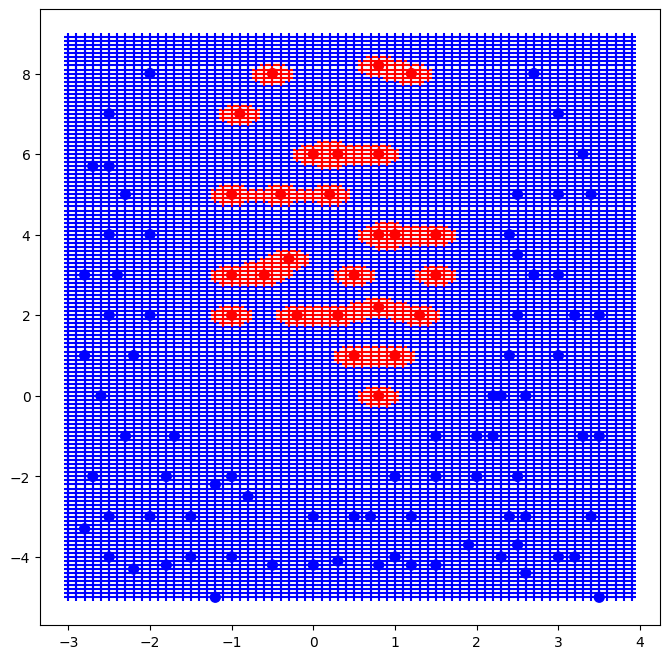

In [95]:
draw_boundary(model_svm, data_train, -3,4,-5,9)

C=0.1   gamma=0.1  train=0.752 val=0.727 n_sv=55
C=0.1   gamma=0.5  train=0.752 val=0.727 n_sv=65
C=0.1   gamma=1    train=0.752 val=0.727 n_sv=77
C=0.1   gamma=2    train=0.752 val=0.727 n_sv=94
C=0.1   gamma=5    train=0.752 val=0.727 n_sv=101
C=1     gamma=0.1  train=1.000 val=1.000 n_sv=33
C=1     gamma=0.5  train=1.000 val=1.000 n_sv=49
C=1     gamma=1    train=1.000 val=1.000 n_sv=72
C=1     gamma=2    train=1.000 val=0.955 n_sv=91
C=1     gamma=5    train=1.000 val=0.818 n_sv=101
C=10    gamma=0.1  train=1.000 val=1.000 n_sv=14
C=10    gamma=0.5  train=1.000 val=1.000 n_sv=41
C=10    gamma=1    train=1.000 val=1.000 n_sv=67


/Users/ardjood/jupyter_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


C=10    gamma=2    train=1.000 val=0.955 n_sv=90
C=10    gamma=5    train=1.000 val=0.818 n_sv=100
C=100   gamma=0.1  train=1.000 val=1.000 n_sv=14
C=100   gamma=0.5  train=1.000 val=1.000 n_sv=41
C=100   gamma=1    train=1.000 val=1.000 n_sv=67
C=100   gamma=2    train=1.000 val=0.955 n_sv=90
C=100   gamma=5    train=1.000 val=0.818 n_sv=100
Selected C, gamma: 10 0.1
Test accuracy: 1.0
Estimated generalization error: 0.0


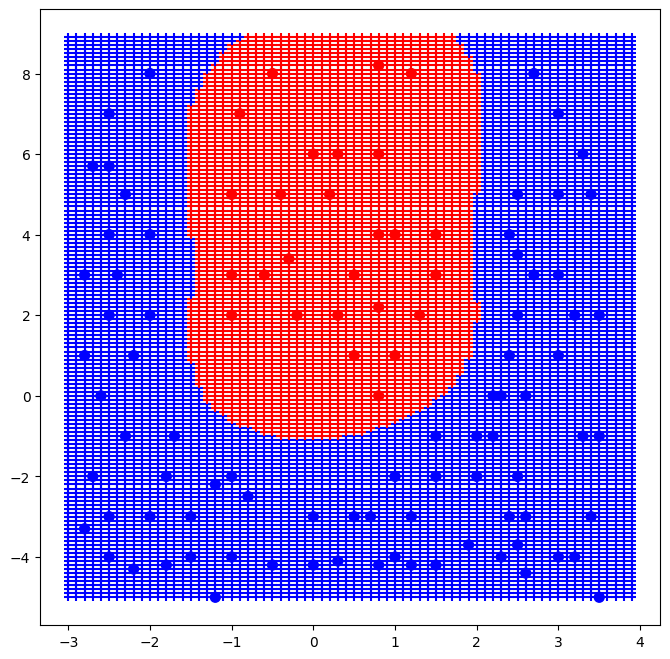

In [96]:
results = []
saved = {}
for C in [0.1, 1, 10, 100]:
    for gamma in [0.1, 0.5, 1, 2, 5]:
        m = svm.SVC(C=C, kernel="rbf", gamma=gamma).fit(data_train.iloc[:, 0:2], data_train.y)
        tr = m.score(data_train.iloc[:, 0:2], data_train.y)
        va = m.score(data_valid.iloc[:, 0:2], data_valid.y)
        print(f"C={C:<5} gamma={gamma:<4} train={tr:.3f} val={va:.3f} n_sv={len(m.support_)}")
        results.append((C, gamma, va, tr, len(m.support_)))
        saved[(C, gamma)] = m

best_val = max(r[2] for r in results)
cands = [r for r in results if r[2] == best_val]
cands.sort(key=lambda r: (r[4], r[0], r[1]))
best_C, best_gamma = cands[0][0], cands[0][1]
best = saved[(best_C, best_gamma)]
print("Selected C, gamma:", best_C, best_gamma)
print("Test accuracy:", best.score(data_test.iloc[:, 0:2], data_test.y))
print("Estimated generalization error:", 1 - best.score(data_test.iloc[:, 0:2], data_test.y))
# Answer: C=10, gamma=0.1 (fewest SVs among models with best val). Test = 1.0 on this small set.
draw_boundary(best, data_train, -3, 4, -5, 9)

In [97]:
print("=== polynomial kernel ===")
best_poly = None
for degree in [2, 3, 4, 5]:
    for C in [0.1, 1, 10]:
        m = svm.SVC(C=C, kernel="poly", degree=degree).fit(data_train.iloc[:, 0:2], data_train.y)
        va = m.score(data_valid.iloc[:, 0:2], data_valid.y)
        print(f"degree={degree} C={C} train={m.score(data_train.iloc[:, 0:2], data_train.y):.3f} val={va:.3f}")
        if best_poly is None or va > best_poly[0]:
            best_poly = (va, degree, C, m)
print("Best poly degree, C:", best_poly[1], best_poly[2])
print("Poly test:", best_poly[3].score(data_test.iloc[:, 0:2], data_test.y))
# RBF is better adapted than poly on this dataset.

=== polynomial kernel ===
degree=2 C=0.1 train=0.752 val=0.727
degree=2 C=1 train=0.790 val=0.727
degree=2 C=10 train=0.838 val=0.773
degree=3 C=0.1 train=0.771 val=0.727
degree=3 C=1 train=0.771 val=0.773
degree=3 C=10 train=0.771 val=0.773
degree=4 C=0.1 train=0.781 val=0.727
degree=4 C=1 train=0.819 val=0.818
degree=4 C=10 train=0.829 val=0.818
degree=5 C=0.1 train=0.781 val=0.727
degree=5 C=1 train=0.810 val=0.773
degree=5 C=10 train=0.819 val=0.818
Best poly degree, C: 4 1
Poly test: 0.6521739130434783


# Exercice 4 : SVM on MNIST data

In [98]:
# Exercise 4 — MNIST: linear SVM on scaled raw pixels, then HOG.
# Fit the scaler on the training set only.
mnist = pd.read_csv("cp_sample.csv", sep=";")
data_train, temp = train_test_split(mnist, test_size=0.30, random_state=4)
data_valid, data_test = train_test_split(temp, test_size=0.50, random_state=4)

scaler = StandardScaler().fit(data_train.iloc[:, 1:])
Xtr = scaler.transform(data_train.iloc[:, 1:])
Xva = scaler.transform(data_valid.iloc[:, 1:])
Xte = scaler.transform(data_test.iloc[:, 1:])
ytr, yva, yte = data_train.label, data_valid.label, data_test.label

print("=== Linear SVM, raw pixels ===")
best = None
saved = {}
for C in [0.1, 1, 10]:
    m = svm.SVC(C=C, kernel="linear").fit(Xtr, ytr)
    va = m.score(Xva, yva)
    print(f"C={C} train={m.score(Xtr, ytr):.4f} val={va:.4f} n_sv={len(m.support_)}")
    saved[C] = m
    if best is None or va > best[1]:
        best = (C, va)
print("Selected C:", best[0])
print("Test:", saved[best[0]].score(Xte, yte))
print("Gen. error:", 1 - saved[best[0]].score(Xte, yte))

=== Linear SVM, raw pixels ===
C=0.1 train=1.0000 val=0.8200 n_sv=531
C=1 train=1.0000 val=0.8200 n_sv=531
C=10 train=1.0000 val=0.8200 n_sv=531
Selected C: 0.1
Test: 0.8933333333333333
Gen. error: 0.10666666666666669


In [99]:
def my_hog(row, ori, cell):
    img = row.iloc[1:].to_numpy().reshape(28, 28)
    return pd.Series(hog(img, orientations=ori, pixels_per_cell=(cell, cell), cells_per_block=(1, 1)))

hog_train = data_train.apply(my_hog, axis=1, args=(8, 4))
hog_valid = data_valid.apply(my_hog, axis=1, args=(8, 4))
hog_test = data_test.apply(my_hog, axis=1, args=(8, 4))
print("HOG shape", hog_train.shape)

print("=== Linear SVM, HOG 8/4 ===")
best = None
saved = {}
for C in [0.1, 1, 10]:
    m = svm.SVC(C=C, kernel="linear").fit(hog_train, ytr)
    va = m.score(hog_valid, yva)
    print(f"C={C} train={m.score(hog_train, ytr):.4f} val={va:.4f}")
    saved[C] = m
    if best is None or va > best[1]:
        best = (C, va)
print("Selected C:", best[0])
print("Test:", saved[best[0]].score(hog_test, yte))
print("Gen. error:", 1 - saved[best[0]].score(hog_test, yte))

print("=== RBF SVM, HOG 8/4 ===")
best = None
saved = {}
for C in [1, 10]:
    for gamma in [0.1, 1]:
        m = svm.SVC(C=C, kernel="rbf", gamma=gamma).fit(hog_train, ytr)
        va = m.score(hog_valid, yva)
        print(f"C={C} gamma={gamma} train={m.score(hog_train, ytr):.4f} val={va:.4f}")
        saved[(C, gamma)] = m
        if best is None or va > best[2]:
            best = (C, gamma, va)
print("Selected:", best[:2])
print("Test:", saved[best[:2]].score(hog_test, yte))
print("Gen. error:", 1 - saved[best[:2]].score(hog_test, yte))

HOG shape (700, 392)
=== Linear SVM, HOG 8/4 ===
C=0.1 train=0.9871 val=0.9133
C=1 train=1.0000 val=0.9067
C=10 train=1.0000 val=0.9067
Selected C: 0.1
Test: 0.88
Gen. error: 0.12
=== RBF SVM, HOG 8/4 ===
C=1 gamma=0.1 train=1.0000 val=0.9333
C=1 gamma=1 train=1.0000 val=0.2000
C=10 gamma=0.1 train=1.0000 val=0.9333
C=10 gamma=1 train=1.0000 val=0.2133
Selected: (1, 0.1)
Test: 0.8933333333333333
Gen. error: 0.10666666666666669
